# Analysis

## Plots

In [1]:
import random
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from vigenere import * 

In [2]:
with open("samples/alice_in_wonderland.txt") as fin:
    content = fin.read()
input_text = normalize_text(content)

In [3]:
def generate_random_key(klen):
    return ''.join([
        random.choice(alphabets)
        for _ in range(klen)
    ])

In [4]:
def select_text_window(text, window_len):
    start = random.choice(range(0, len(text)-window_len))
    return text[start:start+window_len]

In [5]:
n_trial = 20
klen_recover_data = {}
k_recover_data = {}

for klen in [3, 5, 7, 10, 15, 20]:
    for window_len in [100, 200, 500, 1000, 2000, 5000, 20000]:
        for alpha in [0.6, 0.7, 0.8, 0.9]: 
            n_klen_recovered = 0
            n_key_recovered = 0

            for i in range(n_trial):
                key = generate_random_key(klen)
                window = select_text_window(input_text, window_len)
                cipher_text = encrypt_decrypt("encrypt", window, key)
                
                recovered_klen = guess_key_length(cipher_text, alpha)
                recovered_keys = guess_keys(cipher_text, recovered_klen)

                best_key = recovered_keys[0]
                recovered_klen = len(best_key)

                if recovered_klen == klen:
                    n_klen_recovered += 1
                # else: 
                #     print(f"{klen} {window_len} | real klen {klen} -> recovered klen {recovered_klen}")
                if best_key == key:
                    n_key_recovered += 1
                # else:
                #     print(f"{klen} {window_len} | real key {key} -> recovered key {best_key}")
            
            klen_recover_data[(klen, window_len, alpha)] = n_klen_recovered / n_trial
            k_recover_data[(klen, window_len, alpha)] = n_key_recovered / n_trial

In [6]:
klen_df = pd.DataFrame({
    'klen_recover_ratio': klen_recover_data
})
klen_df.index.names = ['klen', 'window_len', 'alpha']
klen_df = klen_df.reset_index()

k_df = pd.DataFrame({
    'k_recover_ratio': k_recover_data,
})
k_df.index.names = ['klen', 'window_len', 'alpha']
k_df = k_df.reset_index()

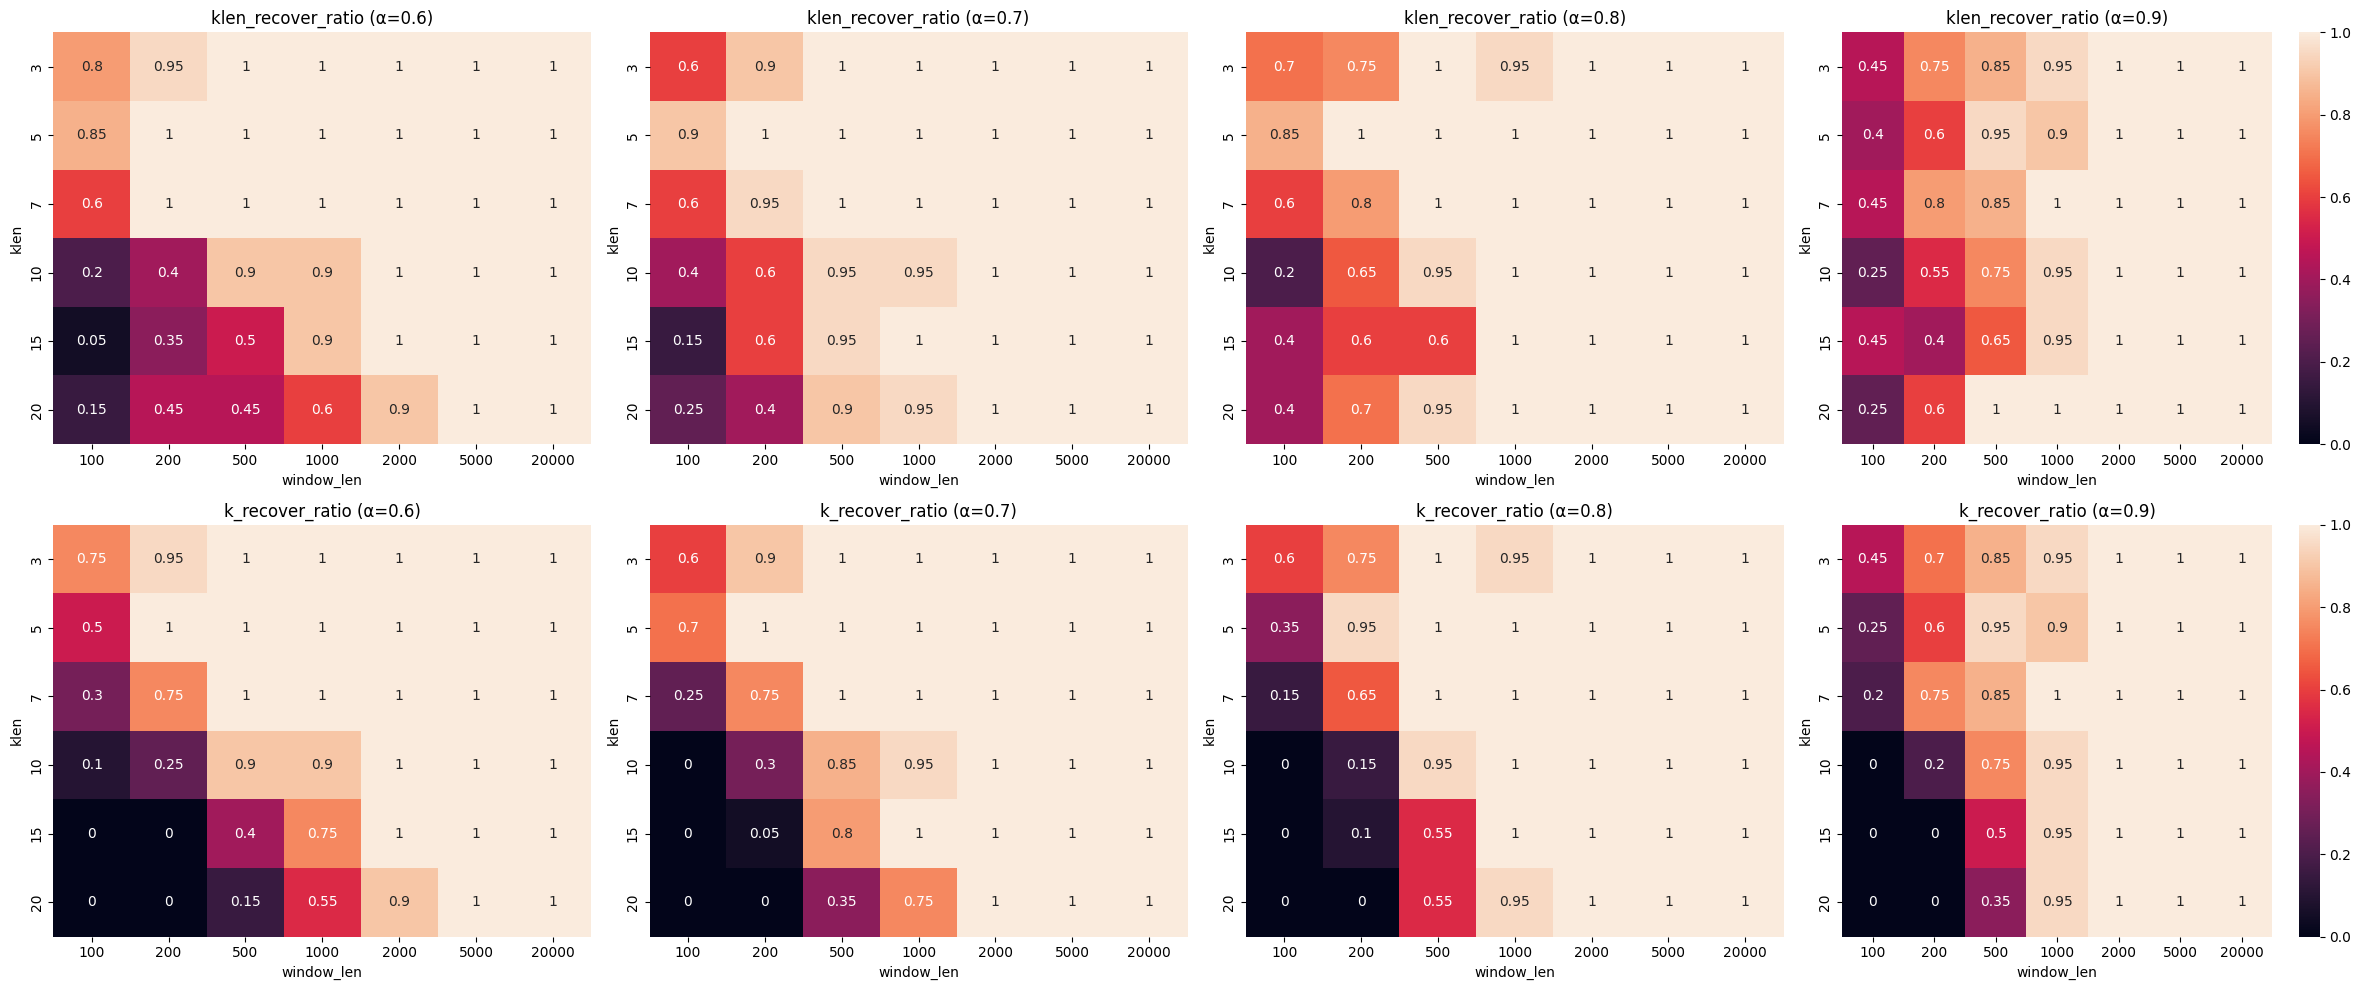

In [7]:
alphas = [0.6, 0.7, 0.8, 0.9]
fig, axes = plt.subplots(2, len(alphas), figsize=(6*len(alphas), 10))

for col, alpha in enumerate(alphas):
    sub_klen = klen_df[klen_df['alpha'] == alpha]
    sub_k = k_df[k_df['alpha'] == alpha]

    pivot1 = sub_klen.pivot(index='klen', columns='window_len', values='klen_recover_ratio')
    pivot2 = sub_k.pivot(index='klen', columns='window_len', values='k_recover_ratio')

    sns.heatmap(pivot1, annot=True, ax=axes[0, col], vmin=0, vmax=1, cbar=col==len(alphas)-1)
    axes[0, col].set_title(f'klen_recover_ratio (α={alpha})')

    sns.heatmap(pivot2, annot=True, ax=axes[1, col], vmin=0, vmax=1, cbar=col==len(alphas)-1)
    axes[1, col].set_title(f'k_recover_ratio (α={alpha})')

plt.tight_layout()
plt.show()

## Answers

We get the best results in the second column when $\alpha = 0.7$. $\alpha$ is a 
variable that I introduced that determines how much weight is given to IOC similarity
($\alpha = 1$) versus how well the candidate key length divides the other candidates.

Key length recovery performance is quite unreliable when cipher length is 100, 
regardless of key length; it performs somewhat better when cipher length increases 
to 200, especially when key length is longer ($\gt 10$); when cipher length is over 
200, the performance becomes fairly reliable across all key lengths. Overall, the 
algorithm performs the worst when cipher length is short while key length is long.

The algorithm behaves this way because of how IoC works. IoC estimates how closely a 
column's letter distribution matches that of English. If a candidate key length is 
the true key length, then in the resulting matrix, every letter in the same column 
is shifted by the same key letter.

If we assume that the original column conforms to a typical English letter 
distribution, then its IOC should be the same after the shift as well. Then, how 
close the column's IoC is to English IoC can be used as a proxy for whether the key 
guess is good. When the column does not conform to the English distribution 
(e.g., when there aren't enough letters), IoC works poorly.

Therefore, when the real key length is long, the matrix is stretched wide and shallow.
In this case, we would also end up with few letters in each column, which is also bad
for IOC analysis. 

Key recovery fails at the same boundary as key length recovery, since key recovery
guesses the key using the given key length produced by key length recovery.